In [83]:
#invite people for the Kaggle party
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [84]:
#bring in the six packs
df_train = pd.read_csv('train.csv')


In [85]:
#check the decoration
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [86]:
df_train.shape

(1460, 81)

In [87]:
#descriptive statistics summary
df_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice', ylabel='Density'>

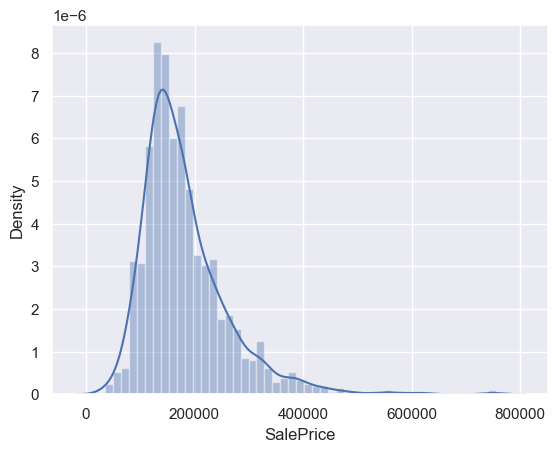

In [88]:
#histogram
sns.distplot(df_train['SalePrice'])
#近似正态分布

In [89]:
#skewness and kurtosis 偏度和峰度
print("Skewness: %f" % df_train['SalePrice'].skew())
print("Kurtosis: %f" % df_train['SalePrice'].kurt())
print(df_train['SalePrice'].skew())
print(f"Skewness:{df_train['SalePrice'].skew()}")

Skewness: 1.882876
Kurtosis: 6.536282
1.8828757597682129
Skewness:1.8828757597682129


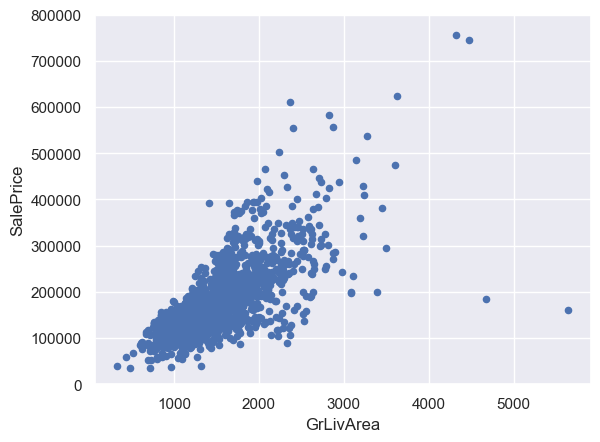

In [90]:
#scatter plot grlivarea/saleprice
var = 'GrLivArea'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000));

In [91]:
a1=(1,2,3,4,5,6,7,8,9)
b1=(11,22,33,44,55,66,77,88,99)
a=pd.Series(a1)
b=pd.Series(b1)
c=pd.concat([a,b],axis=0)
d=pd.concat([a,b],axis=1)
print('c:',c)
print('d:',d)

c: 0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
0    11
1    22
2    33
3    44
4    55
5    66
6    77
7    88
8    99
dtype: int64
d:    0   1
0  1  11
1  2  22
2  3  33
3  4  44
4  5  55
5  6  66
6  7  77
7  8  88
8  9  99


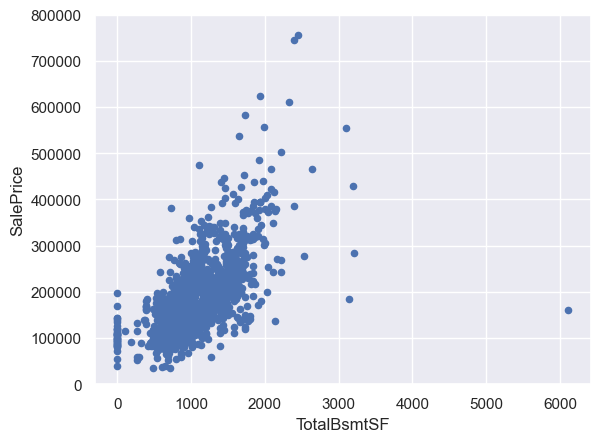

In [92]:
#scatter plot totalbsmtsf/saleprice
var = 'TotalBsmtSF'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice' ,ylim=(0,800000));

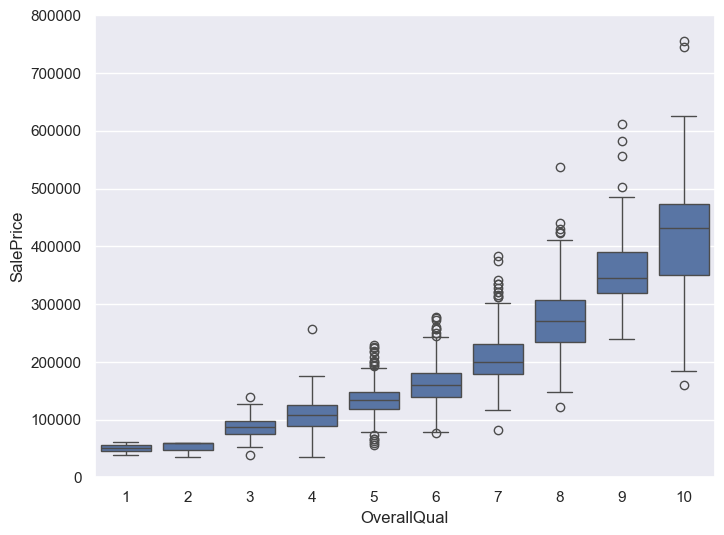

In [93]:
#box plot overallqual/saleprice
var = 'OverallQual'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
f, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000);

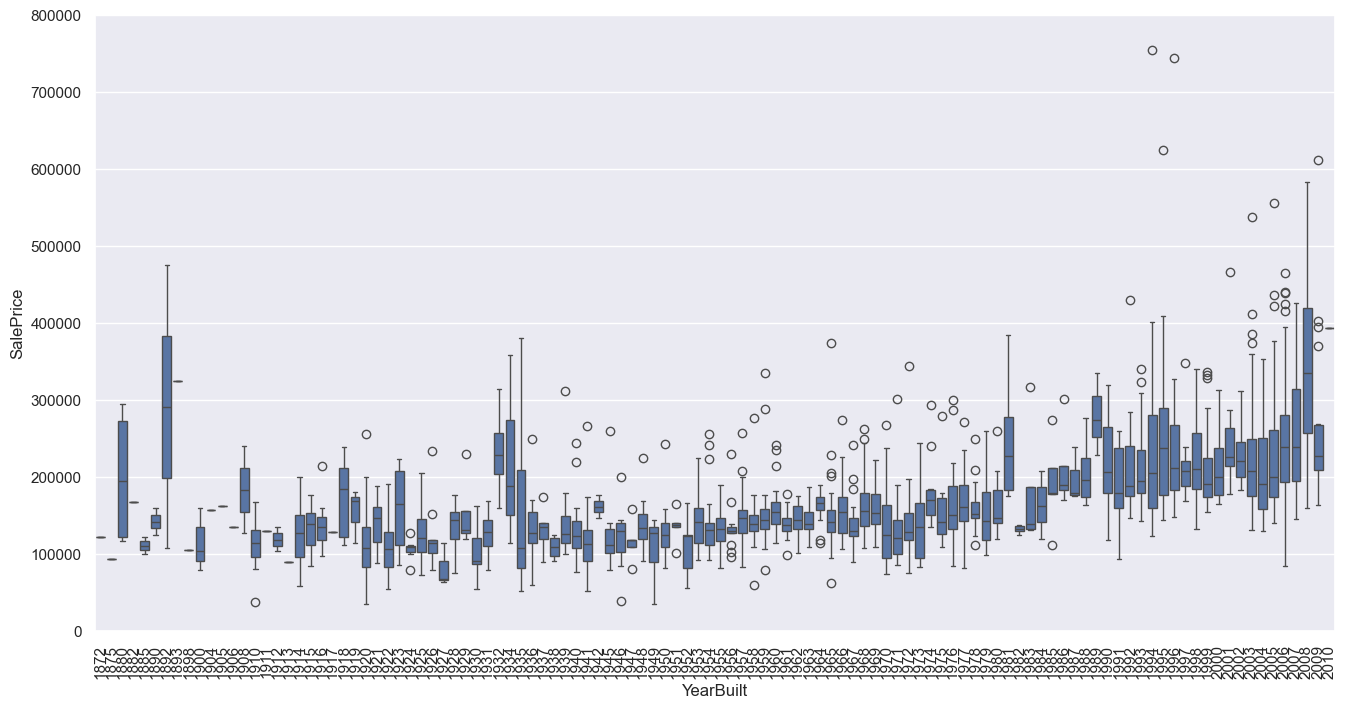

In [94]:
var = 'YearBuilt'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
f, ax = plt.subplots(figsize=(16, 8))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000);
plt.xticks(rotation=90);

In [95]:
# objective analysis
print(df_train.dtypes)

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


<Axes: >

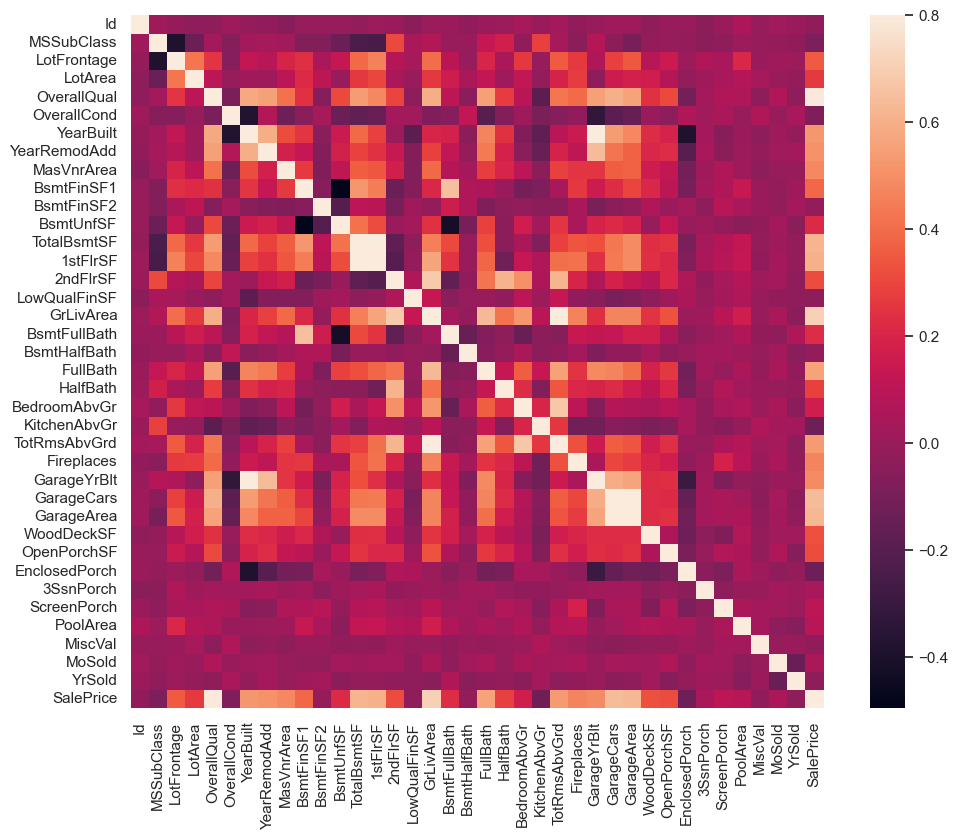

In [96]:
#correlation matrix
#corrmat = df_train.corr() 
#f, ax = plt.subplots(figsize=(12, 9))  
#sns.heatmap(corrmat, vmax=.8, square=True)

## 修改后的代码：只分析数值变量
# 首先选择数值型列
numerical_df = df_train.select_dtypes(include=['int64', 'float64'])

# correlation matrix
corrmat = numerical_df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)


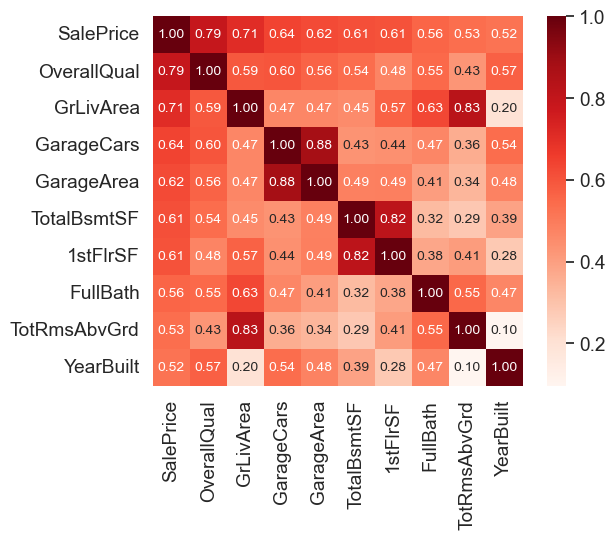

In [97]:
#saleprice correlation matrix
k = 10 #number of variables for heatmap
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
#value转换成np能计算的格式，T：行变列，列变行。
cm = np.corrcoef(df_train[cols].values.T)
#设置字体大小为1.25倍，这个字体是轴标签字体
sns.set(font_scale=1.25)
#cbar是颜色，annot是显示数据（格子里边的数值），后边的_kws是该数值的大小，square是显示为正方形，
#fmt是显示两位小数（.2f）
#最后yticklabels是y轴标签是哪些特征的名称，x轴一样
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, 
                 fmt='.2f', annot_kws={'size': 10}, 
                 yticklabels=cols.values, xticklabels=cols.values,
                cmap='Reds')
plt.show()

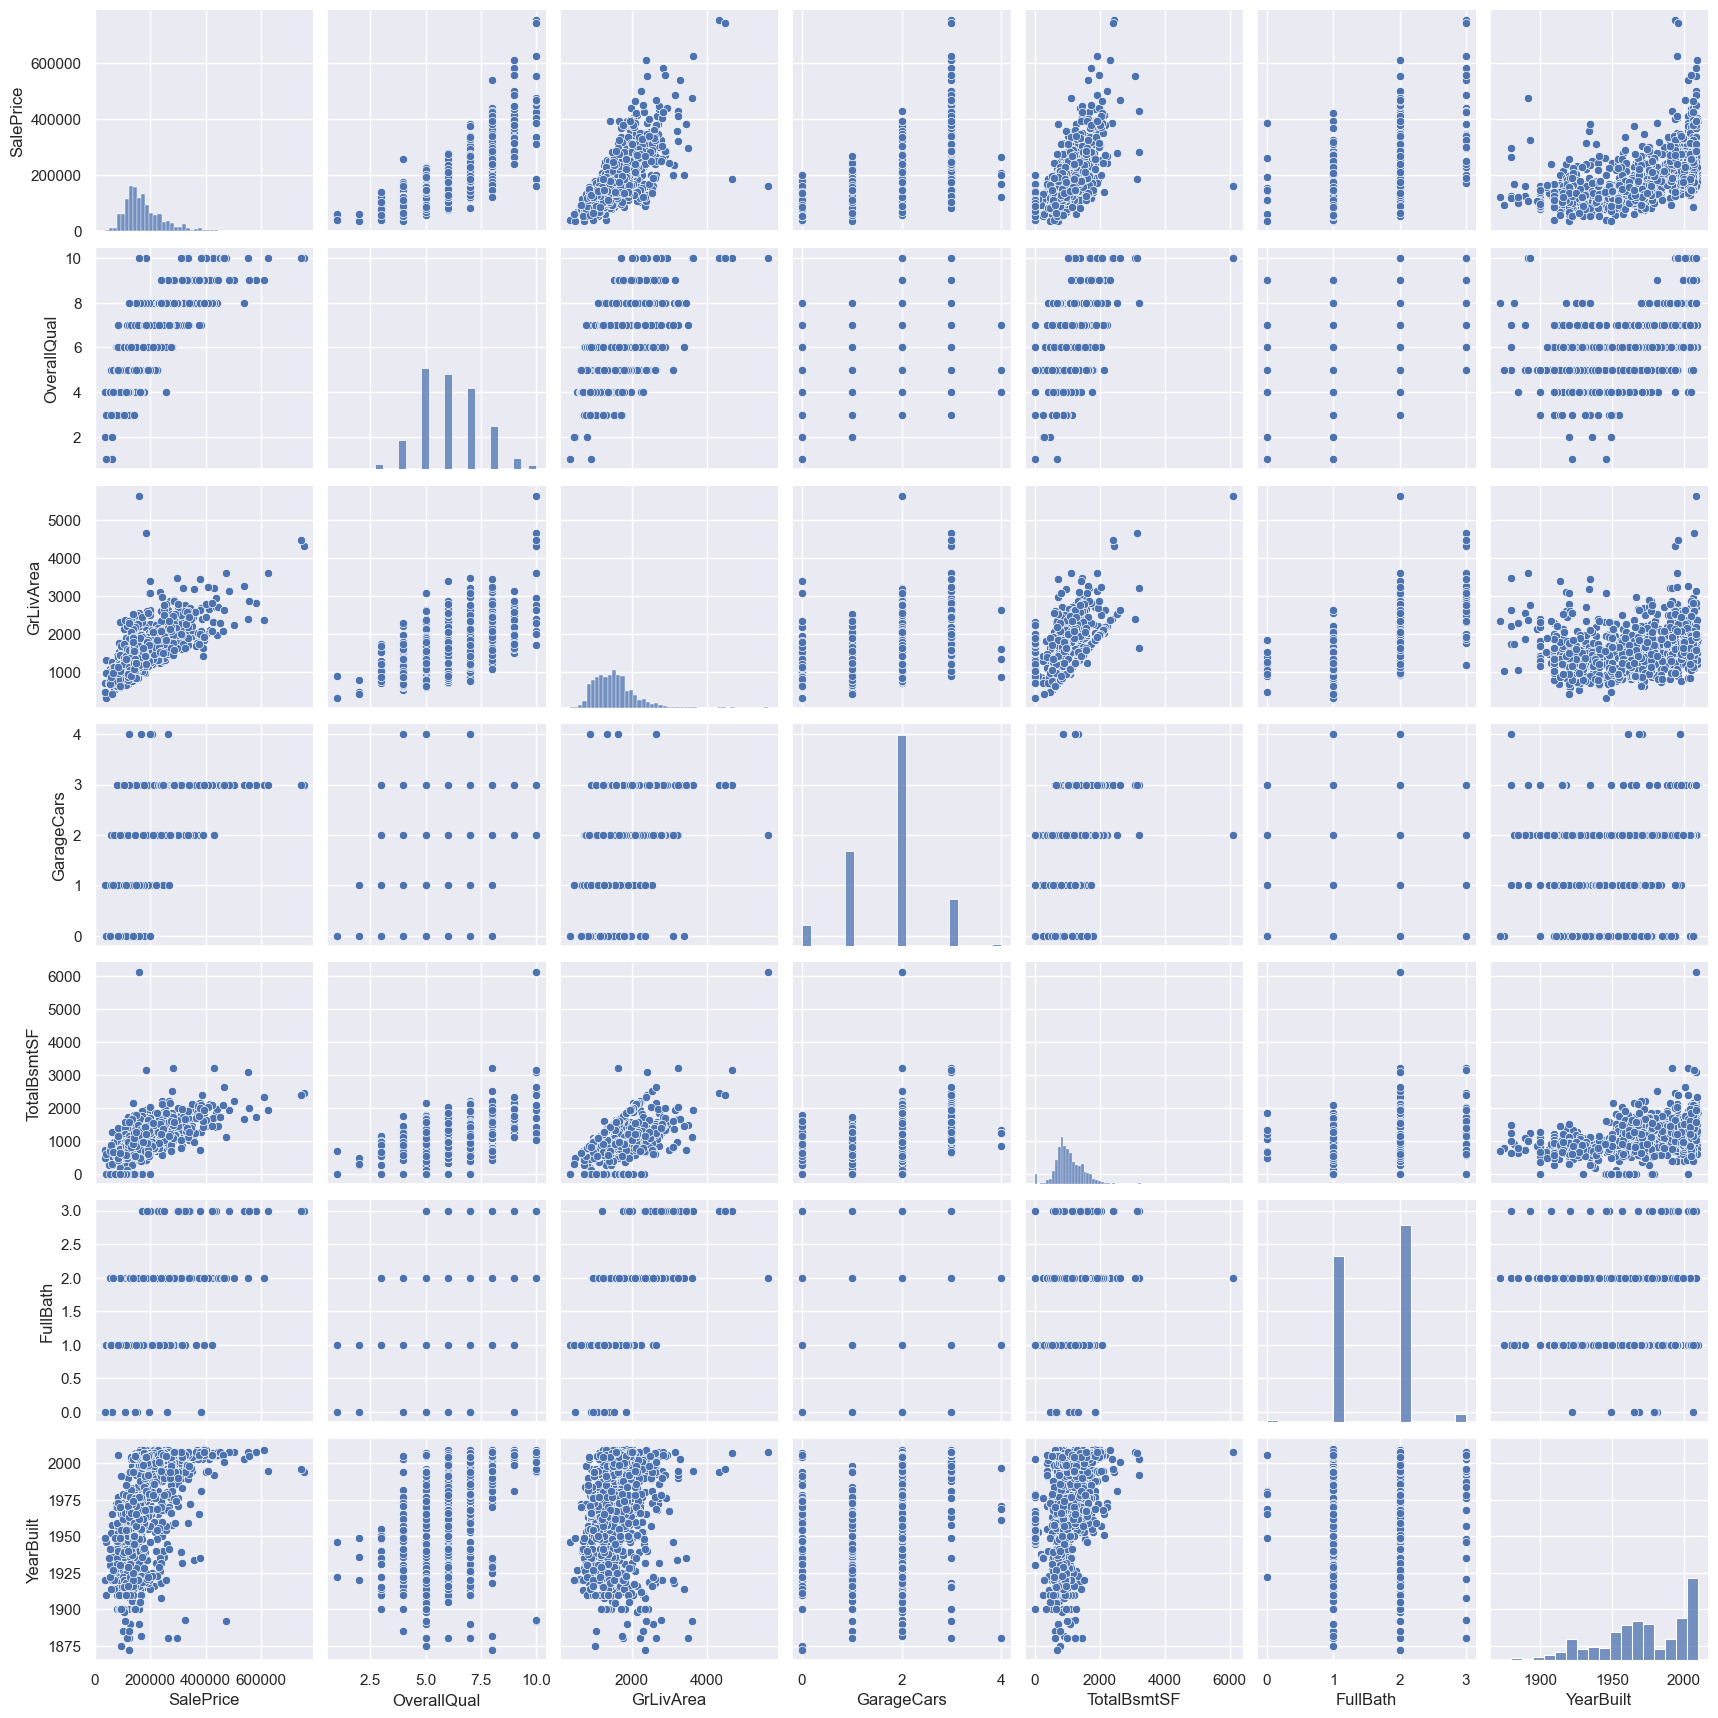

In [98]:
#scatterplot
sns.set()
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.pairplot(df_train[cols], size = 2.5)
plt.show();

In [99]:
#missing data 
#sort_values(ascending=False)是降序的意思，ture是升序
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])  #keys是键，给每一列从新命名
missing_data.head(20)

,Total,Percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageYrBlt,81,0.055479
GarageCond,81,0.055479
GarageType,81,0.055479


In [100]:
#该code中代码，单独运行会报错
#dealing with missing data， drop是删除
df_train = df_train.drop((missing_data[missing_data['Total'] > 1]).index,axis=1)
df_train = df_train.drop(df_train.loc[df_train['Electrical'].isnull()].index)
df_train.isnull().sum().max() #just checking that there's no missing data missing...

0

In [101]:
#standardizing data
saleprice_scaled = StandardScaler().fit_transform(df_train['SalePrice'].values.reshape(-1,1));
low_range = saleprice_scaled[saleprice_scaled[:,0].argsort()][:10]
high_range= saleprice_scaled[saleprice_scaled[:,0].argsort()][-10:]
print('outer range (low) of the distribution:')
print(low_range)
print('\nouter range (high) of the distribution:')
print(high_range)

outer range (low) of the distribution:
[[-1.83820775]
 [-1.83303414]
 [-1.80044422]
 [-1.78282123]
 [-1.77400974]
 [-1.62295562]
 [-1.6166617 ]
 [-1.58519209]
 [-1.58519209]
 [-1.57269236]]

outer range (high) of the distribution:
[[3.82758058]
 [4.0395221 ]
 [4.49473628]
 [4.70872962]
 [4.728631  ]
 [5.06034585]
 [5.42191907]
 [5.58987866]
 [7.10041987]
 [7.22629831]]


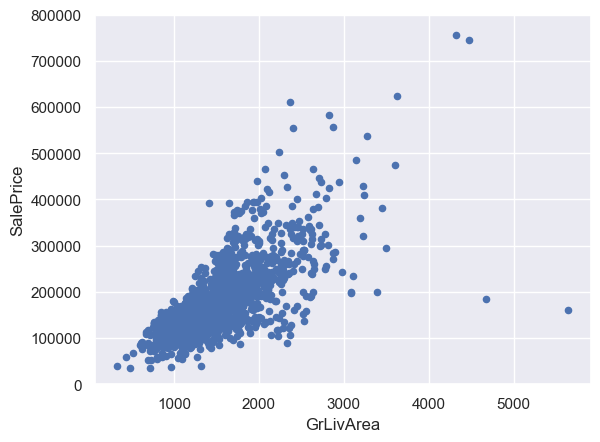

In [102]:
#bivariate analysis saleprice/grlivarea
var = 'GrLivArea'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000));

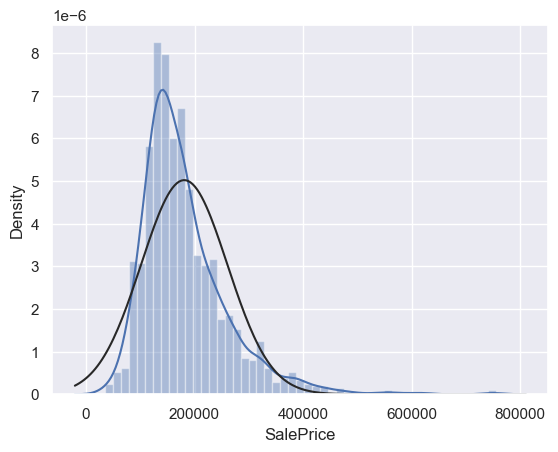

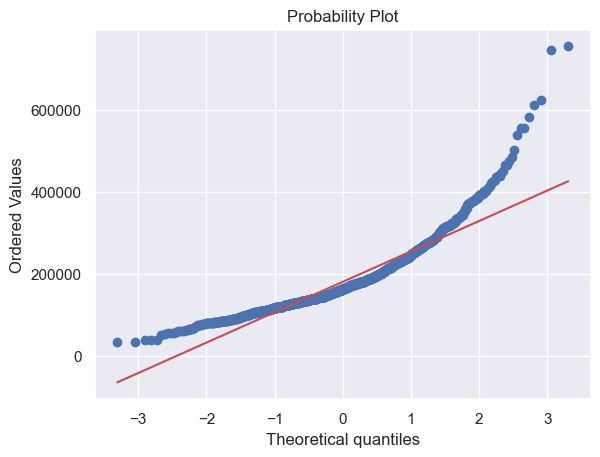

In [103]:
#histogram and normal probability plot
sns.distplot(df_train['SalePrice'], fit=norm);
fig = plt.figure()
res = stats.probplot(df_train['SalePrice'], plot=plt)

In [104]:
#applying log transformation
df_train['SalePrice'] = np.log(df_train['SalePrice'])

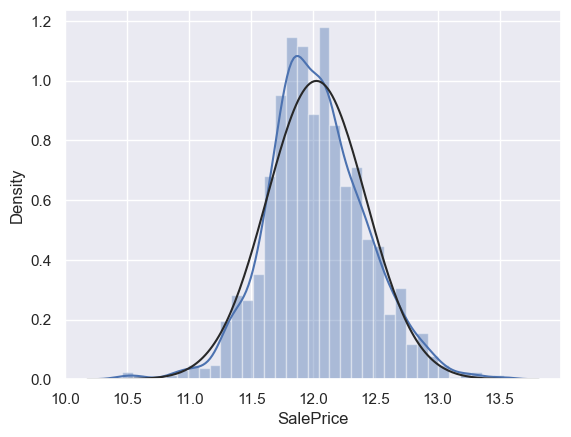

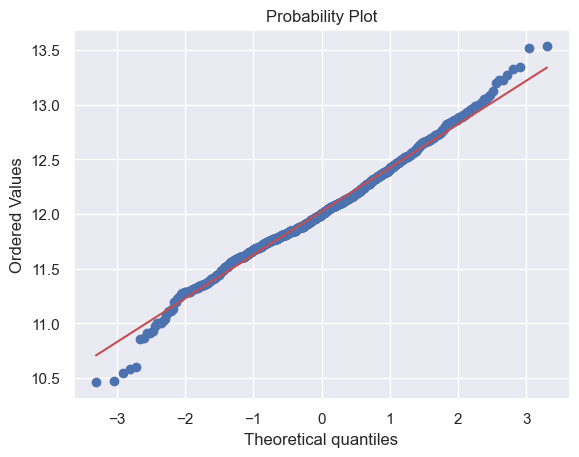

In [105]:
#transformed histogram and normal probability plot
sns.distplot(df_train['SalePrice'], fit=norm);
fig = plt.figure()
res = stats.probplot(df_train['SalePrice'], plot=plt)

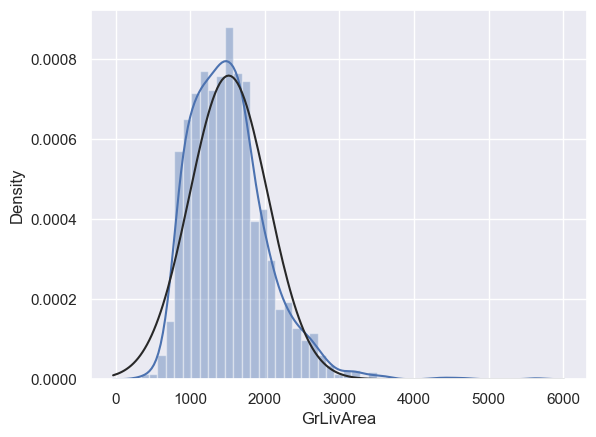

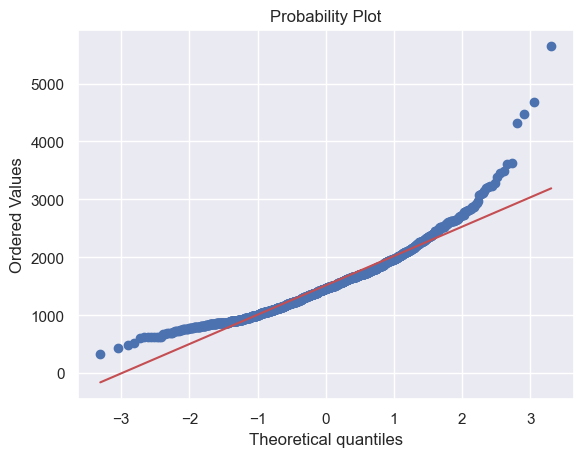

In [106]:
#histogram and normal probability plot
sns.distplot(df_train['GrLivArea'], fit=norm);
fig = plt.figure()
res = stats.probplot(df_train['GrLivArea'], plot=plt)


In [107]:
#data transformation
df_train['GrLivArea'] = np.log(df_train['GrLivArea'])

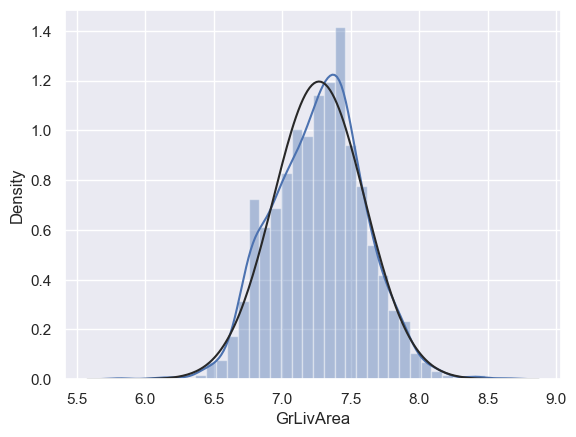

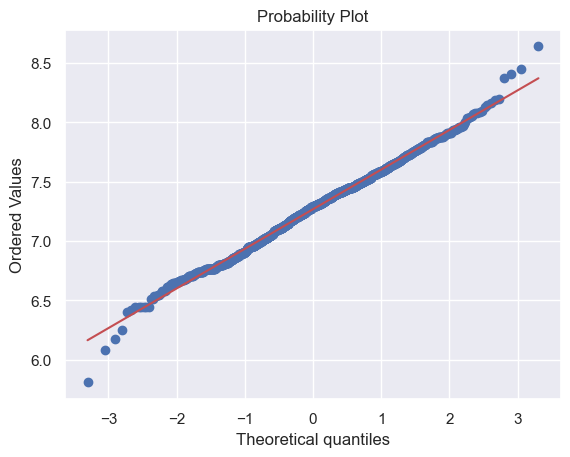

In [108]:
#transformed histogram and normal probability plot
sns.distplot(df_train['GrLivArea'], fit=norm);
fig = plt.figure()
res = stats.probplot(df_train['GrLivArea'], plot=plt)


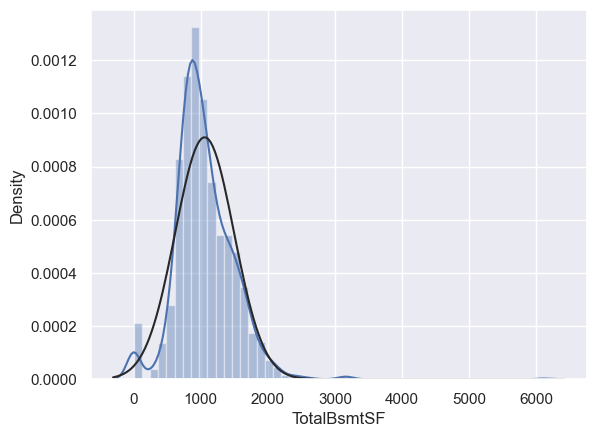

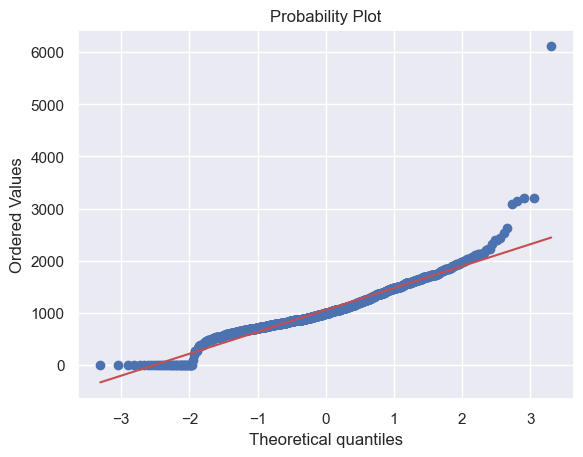

In [109]:
#histogram and normal probability plot
sns.distplot(df_train['TotalBsmtSF'], fit=norm);
fig = plt.figure()
res = stats.probplot(df_train['TotalBsmtSF'], plot=plt)


In [110]:
#create column for new variable (one is enough because it's a binary categorical feature)
#if area>0 it gets 1, for area==0 it gets 0
#将地下室面积转换成了是否有地下室这样的分类变量，即面积是0，代表没有地下室，0；面积大于0，代表有地下室，1
#这是一行多余的代码：
#df_train['HasBsmt'] = pd.Series(len(df_train['TotalBsmtSF']), index=df_train.index)

df_train['HasBsmt'] = 0 
df_train.loc[df_train['TotalBsmtSF']>0,'HasBsmt'] = 1

In [111]:
#transform data
df_train.loc[df_train['HasBsmt']==1,'TotalBsmtSF'] = np.log(df_train['TotalBsmtSF'])

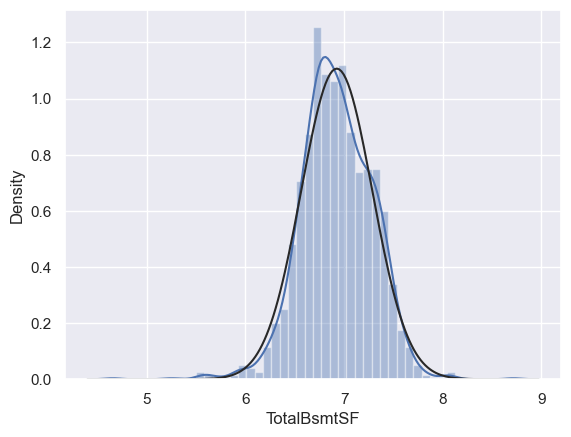

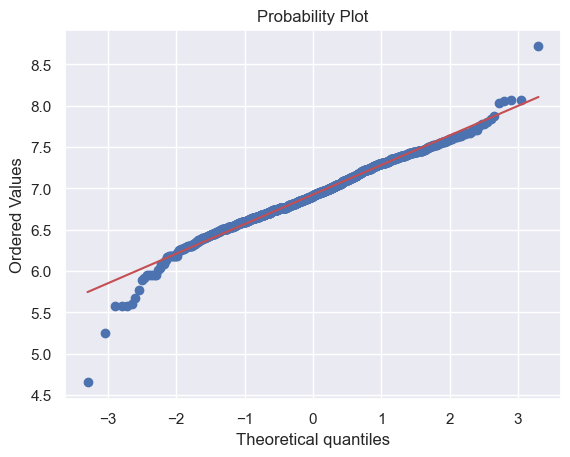

In [112]:
#histogram and normal probability plot
sns.distplot(df_train[df_train['TotalBsmtSF']>0]['TotalBsmtSF'], fit=norm);
fig = plt.figure()
res = stats.probplot(df_train[df_train['TotalBsmtSF']>0]['TotalBsmtSF'], plot=plt)

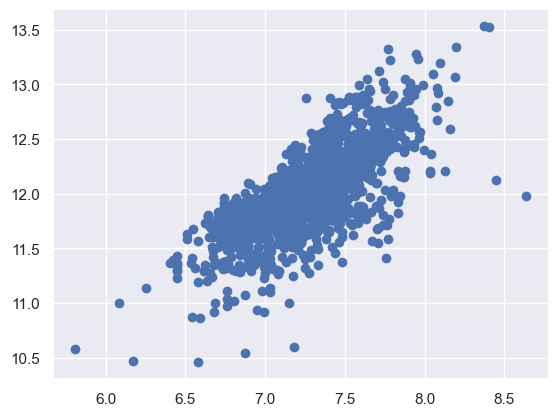

In [113]:
#scatter plot
plt.scatter(df_train['GrLivArea'], df_train['SalePrice']);

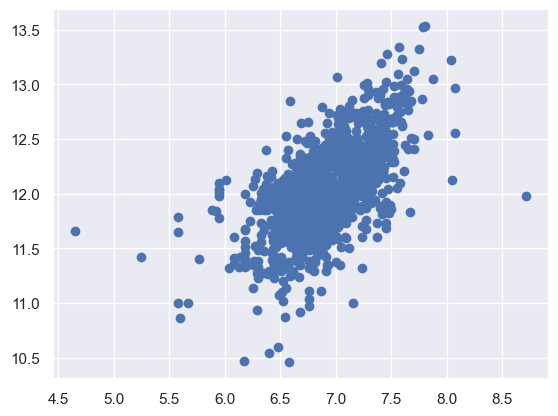

In [114]:
#scatter plot
plt.scatter(df_train[df_train['TotalBsmtSF']>0]['TotalBsmtSF'], df_train[df_train['TotalBsmtSF']>0]['SalePrice']);

In [115]:
#convert categorical variable into dummy
df_train = pd.get_dummies(df_train)

In [116]:
# 1. 准备特征矩阵 X 和目标向量 y
# 注意：目标变量 'SalePrice' 已经是经过对数转换的值
y = df_train['SalePrice'].values
X = df_train.drop(['SalePrice'], axis=1)

# 2. 划分训练集和验证集（用于评估模型，防止过拟合）
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"训练集大小： {X_train.shape}， 验证集大小： {X_val.shape}")

训练集大小： (1167, 222)， 验证集大小： (292, 222)


In [117]:
#line

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. 创建并训练模型
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. 在验证集上进行预测
y_val_pred = lr_model.predict(X_val)

# 3. 评估模型性能（由于y是取过对数的，误差也是对数尺度）
# 常用的评估指标是均方根误差 (RMSE)
lr_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f'线性回归模型在验证集上的RMSE（对数尺度）为：{lr_rmse:.4f}')

# （可选）将预测值转换回原始房价尺度，计算更直观的误差
# 注意：np.expm1 是 np.log1p 的逆运算，但你是用 np.log 转换的，所以用 np.exp
y_val_exp = np.exp(y_val)
y_val_pred_exp = np.exp(y_val_pred)
lr_rmse_exp = np.sqrt(mean_squared_error(y_val_exp, y_val_pred_exp))
print(f'线性回归模型在验证集上的RMSE（原始房价尺度）约为：${lr_rmse_exp:,.2f}')

线性回归模型在验证集上的RMSE（对数尺度）为：0.1216
线性回归模型在验证集上的RMSE（原始房价尺度）约为：$20,398.09


In [118]:
#randomforest
from sklearn.ensemble import RandomForestRegressor

# 1. 创建并训练随机森林回归模型
# 先使用一组默认参数，n_estimators（树的数量）可以设大一些
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. 在验证集上预测并评估
y_val_pred_rf = rf_model.predict(X_val)
rf_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
print(f'随机森林模型在验证集上的RMSE（对数尺度）为：{rf_rmse:.4f}')

# 比较两个模型
print(f'\n模型比较（RMSE对数尺度，越低越好）：')
print(f'  线性回归: {lr_rmse:.4f}')
print(f'  随机森林: {rf_rmse:.4f}')

随机森林模型在验证集上的RMSE（对数尺度）为：0.1390

模型比较（RMSE对数尺度，越低越好）：
  线性回归: 0.1216
  随机森林: 0.1390


In [122]:
print(df_test_processed.isnull().sum().sort_values(ascending=False).head(10))


BsmtHalfBath           2
BsmtFullBath           2
TotalBsmtSF            1
GarageCars             1
GarageArea             1
BsmtFinSF1             1
BsmtFinSF2             1
BsmtUnfSF              1
Exterior2nd_HdBoard    0
Exterior2nd_MetalSd    0
dtype: int64


In [125]:
# 用0填充所有缺失值
df_test_processed.fillna(0, inplace=True)
print(df_test_processed.isnull().sum().sort_values(ascending=False).head(10))

# 然后再预测
final_predictions_log = lr_model.predict(df_test_processed)

Id                     0
Exterior2nd_MetalSd    0
Exterior1st_VinylSd    0
Exterior1st_Wd Sdng    0
Exterior1st_WdShing    0
Exterior2nd_AsbShng    0
Exterior2nd_AsphShn    0
Exterior2nd_Brk Cmn    0
Exterior2nd_BrkFace    0
Exterior2nd_CBlock     0
dtype: int64


In [126]:
# 1. 加载测试集
df_test = pd.read_csv('test.csv')
test_id = df_test['Id'] # 保存Id用于最终提交

# 2. 进行与训练集完全相同的预处理！
# 这里需要把你之前对 df_train 做的所有清洗、变换步骤，对 df_test 重做一遍。
# 例如：处理缺失值、对 ‘GrLivArea‘, ‘TotalBsmtSF‘ 进行 np.log 变换、创建 ‘HasBsmt‘ 列等。
# **注意：这是一个容易出错的关键步骤，务必保持一致。**

# 假设你已将测试集处理完毕，并命名为 df_test_processed
# 同时，要确保 df_test_processed 的列与 X_train 完全一致（独热编码后维度可能不同）
# 使用 .reindex 和 .fillna 对齐列
df_test_processed = df_test.reindex(columns=X.columns, fill_value=0)

# 3. 用训练好的最佳模型进行预测
final_predictions_log = lr_model.predict(df_test_processed) # 这是对数尺度的预测

# 4. 将对数预测值转换回原始房价尺度
final_predictions = np.exp(final_predictions_log)

# 5. 创建提交文件
submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': final_predictions
})
submission.to_csv('my_submission.csv', index=False)

print("提交文件前几行：")
print(submission.head())

print(f"\n提交文件形状：{submission.shape}")
print(f"ID列是否有重复：{submission['Id'].duplicated().any()}")
print(f"房价是否有空值：{submission['SalePrice'].isnull().any()}")
print(f"房价最小值：${submission['SalePrice'].min():,.2f}")
print(f"房价最大值：${submission['SalePrice'].max():,.2f}")
print(f"房价平均值：${submission['SalePrice'].mean():,.2f}")


print('提交文件 “my_submission.csv” 已生成！')

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values